# Imports

In [12]:
import os
import numpy as np
import tensorflow as tf

In [26]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


# Load and Prepare Data

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [15]:
# Load the data back to verify
save_dir = "/home/mrsarti/git_repos/rANN/data/neurological"
data = np.load(os.path.join(save_dir, "neurological_data.npz"))
print("Keys in the loaded data:", list(data.keys()))

Keys in the loaded data: ['x', 'y', 'x_train', 'x_test', 'y_train', 'y_test', 'ITD_data', 'ILD_data', 'Az', 'El', 'f']


In [16]:
# Get the training and testing data
x_train = data['x_train']
y_train = data['y_train']
x_test = data['x_test']
y_test = data['y_test']

In [17]:
# Normalize features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)

# Split into train/test
x_tr, x_te, y_tr, y_te = train_test_split(
    x_train_scaled, y_train, test_size=0.2, random_state=42
)

# Convert to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((x_tr, y_tr)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((x_te, y_te)).batch(32)

# Build regression model for [azimuth, elevation]
input_dim = x_train_scaled.shape[1]
output_dim = y_train.shape[1]

W0000 00:00:1789168768.515914   23784 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1789168768.523568   23784 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1789168768.600575   23784 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1438 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


# Create & Test simple rANN Model

In [22]:
from scripts.rANN_model import rANN, PerTargetMAECallback, TargetMAE
from scripts.sweep_config import plot_training_history

In [ ]:
# Create callback for per-target MAE
ptcb = PerTargetMAECallback(x_test, y_test, x_train=x_train, y_train=y_train)

# Creates an all to all rANN model
model = rANN(
        input_dim    = input_dim,
        output_dim   = output_dim,
        n_spines     = 64,
        n_dendrites_per_soma = 16,
        n_soma       = 64,
        spine_mask    = None,
        dendrite_mask = None,
        soma_mask     = None,
    )

model.compile(
    optimizer = 'adam', #tf.keras.optimizers.Adam(learning_rate=lr),
    loss      = tf.keras.losses.MeanSquaredError(),
    metrics   = [
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.Accuracy(name="accuracy"),
        TargetMAE(0, name="mae_az"),
        TargetMAE(1, name="mae_el"),
    ],
)

/home/mrsarti/git_repos/rANN/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1789168970.346454   25655 service.cc:153] XLA service 0x7dda10033760 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789168970.346465   25655 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Ti, Compute Capability 12.0a (Driver: 13.0.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1789168970.384613   25655 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1789168970.518214   25655 cuda_dnn.cc:461] Loaded cuDNN version 92300
I0000 00:00:1789168970.525472   25655 dot_merger.cc:48

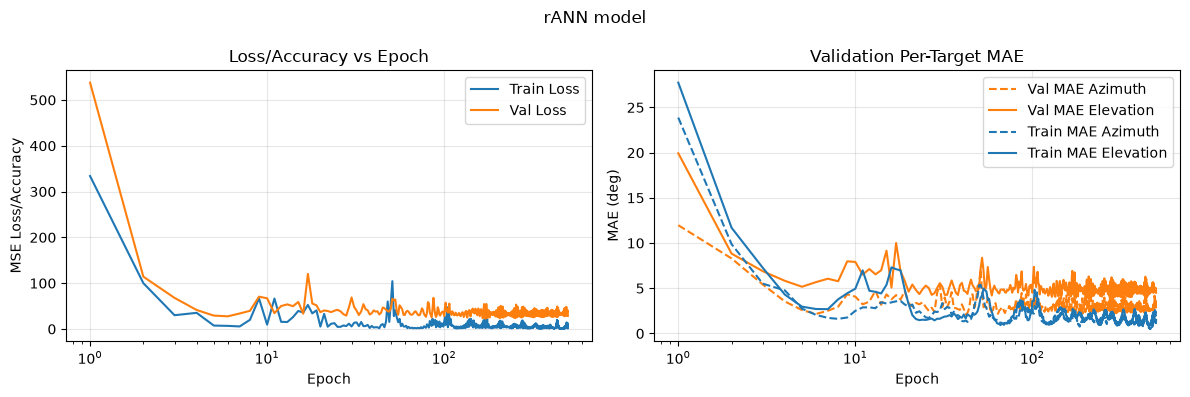

In [23]:
# Train and record loss + per-target MAE directly from Keras history
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=500,
    verbose=0,

)

history_dict = history.history
plot_training_history(history_dict, run_name='rANN model', show=False)

# Training sweep 

In [52]:
import scripts.sweep_config
import importlib
sweep_config = importlib.reload(scripts.sweep_config)
from scripts.sweep_config import build_sweep_configs, run_sweep_from_configs

In [53]:
# Build all configs (generates masks on disk, returns JSON-safe list)
configs = build_sweep_configs(
    output_root          = "/home/mrsarti/git_repos/rANN/model_configs/spine_swath",
    spine_sizes          = [3848],
    dendrite_per_soma_sizes = [5],
    soma_sizes           = [128],
    itd_spine_frac_names = ["equal_split"],
    overlap_names        = ["strict"],
    dendrite_rules       = ["topographic"],
    channel_dend_split_names = ["split"],
    #spine_activations     = ["relu", "sigmoid", "linear"],
    spine_activations     = ["relu","sigmoid","linear"],
    input_dim            = x_train_scaled.shape[1],
    output_dim           = y_train.shape[1],
)

Building 6 configs (1 size × 1 topology × 3 activation + 3 (+ baseline))…
  Reused mask → /home/mrsarti/git_repos/rANN/model_configs/spine_swath/constrained_s3848_d5ps_so128_ifequal_split_ovstrict_drtopographic_cdsplit/mask.npz
  Reused mask → /home/mrsarti/git_repos/rANN/model_configs/spine_swath/alltoall_s3848_d5ps_so128/mask.npz
  Reused mask → /home/mrsarti/git_repos/rANN/model_configs/spine_swath/constrained_s3848_d5ps_so128_ifequal_split_ovstrict_drtopographic_cdsplit/mask.npz
  Reused mask → /home/mrsarti/git_repos/rANN/model_configs/spine_swath/alltoall_s3848_d5ps_so128/mask.npz
  Reused mask → /home/mrsarti/git_repos/rANN/model_configs/spine_swath/constrained_s3848_d5ps_so128_ifequal_split_ovstrict_drtopographic_cdsplit/mask.npz
  Reused mask → /home/mrsarti/git_repos/rANN/model_configs/spine_swath/alltoall_s3848_d5ps_so128/mask.npz
Done — 6 configs ready.


In [54]:
df = run_sweep_from_configs(
        configs= configs,
        training_data = (x_train, y_train),    
        testing_data = (x_test, y_test),
        plot_history = True,
        plot_weights = True,
        output_root = "//home/mrsarti/git_repos/rANN/sweep_results/test"
    )


[1/6]  constrained_s3848_d5ps_so128_ifequal_split_ovstrict_drtopographic_cdsplit


ValueError: Exception encountered when calling rANN.call().

[1mDimensions must be equal, but are 3848 and 768 for '{{node r_ann_2_1/spine_layer/Mul}} = Mul[T=DT_FLOAT](r_ann_2_1/spine_layer/Mul/ReadVariableOp, r_ann_2_1/spine_layer/Mul/ReadVariableOp_1)' with input shapes: [3848,3848], [768,3848].[0m

Arguments received by rANN.call():
  • inputs=tf.Tensor(shape=(None, 3848), dtype=float32)
  • training=True